# Data Exploration

In [32]:
# imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import librosa 
import random 
import IPython.display as ipd


Used Librosa model for the audio handling and conversion of audio into graphs and spectrogram.
Used IPython.display for the audio ui and to listen the audio.

File paths to folders

In [33]:
WILDLIFE_PATH = "../datasets/processed/wildlife/"
THREAT_PATH = "../datasets/processed/threat/"

In [ ]:
wildlife_folder = os.listdir(WILDLIFE_PATH)
threat_folder = os.listdir(THREAT_PATH)

Check for the duration of the files in the folder.

In [47]:
wildlife_duration=[]

for file in os.listdir(WILDLIFE_PATH):
    if file.endswith(".wav"):
        path = os.path.join(WILDLIFE_PATH,file)

        y,sr = librosa.load(path,sr=None)

        wildlife_duration.append(len(y)/sr)

print(f"min Duration : {min(wildlife_duration):.2f} sec")
print(f"max Duration : {max(wildlife_duration):.2f} sec")
print(f"mean Duration : {sum(wildlife_duration)/len(wildlife_duration):.2f} sec")

min Duration : 5.00 sec
max Duration : 5.00 sec
mean Duration : 5.00 sec


All audio samples in the wildlife folder have uniform duration of approx 5sec. 

In [49]:
threat_duration=[]

for file in os.listdir(THREAT_PATH):
    if file.endswith(".wav"):
        path = os.path.join(THREAT_PATH,file)

        y,sr = librosa.load(path,sr=None)

        threat_duration.append(len(y)/sr)

print(f"min Duration : {min(threat_duration):.2f} sec")
print(f"max Duration : {max(threat_duration):.2f}sec")
print(f"mean Duration : {sum(threat_duration)/len(threat_duration):.2f} sec")

min Duration : 5.00 sec
max Duration : 5.00sec
mean Duration : 5.00 sec


All audio samples in the threat folder have uniform duration of approx 5sec. 

In [35]:
wildlife_filename = random.choice(wildlife_folder)
threat_filename = random.choice(threat_folder)

Loading one file from each folder randomly. 

In [36]:
wildlife_sample = WILDLIFE_PATH + wildlife_filename
threat_sample = THREAT_PATH + threat_filename

In [37]:
wildlife_audio,wildlife_sr = librosa.load(wildlife_sample)
threat_audio,threat_sr = librosa.load(threat_sample)

Checking the duration

In [38]:
print(f"wildlife audio duration : {librosa.get_duration(y=wildlife_audio,sr=wildlife_sr)} sec")
print(f"threat audio duration : {librosa.get_duration(y=threat_audio,sr=threat_sr)} sec")

wildlife audio duration : 5.0 sec
threat audio duration : 5.0 sec


Plotting of Wildlife sample- Amplitude vs Time

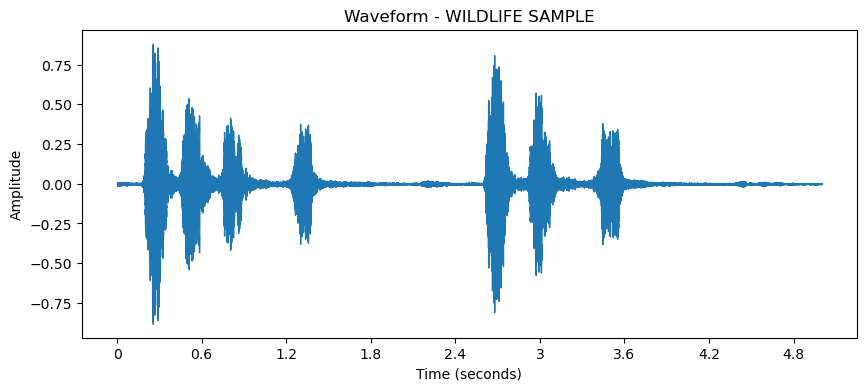

In [39]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(wildlife_audio, sr=wildlife_sr)
plt.title(f"Waveform - WILDLIFE SAMPLE")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

Wildlife audio sample

In [40]:
ipd.Audio(wildlife_audio,rate=wildlife_sr)

Spectrogram of the Wildlife audio

In [41]:
mel_spectrogram = librosa.feature.melspectrogram(y=wildlife_audio, sr=wildlife_sr, n_mels=128)
mel_s_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

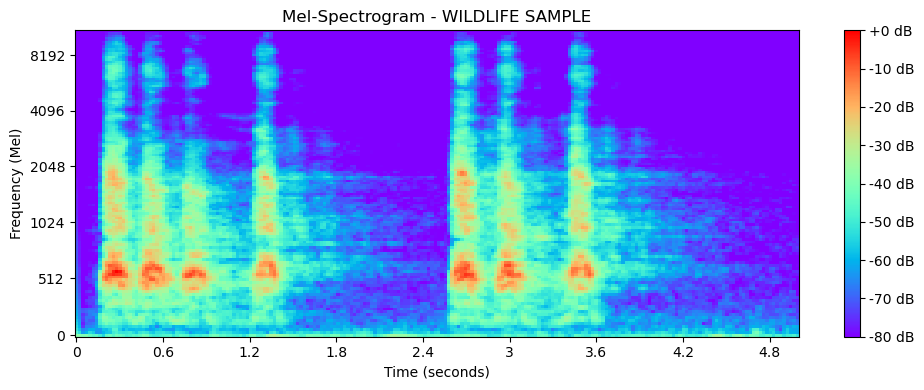

In [42]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_s_db, sr=wildlife_sr, x_axis='time', y_axis='mel', cmap='rainbow')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel-Spectrogram - WILDLIFE SAMPLE")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Mel)")
plt.tight_layout()
plt.show()

Plotting of Threat audio - Amplitude vs Time

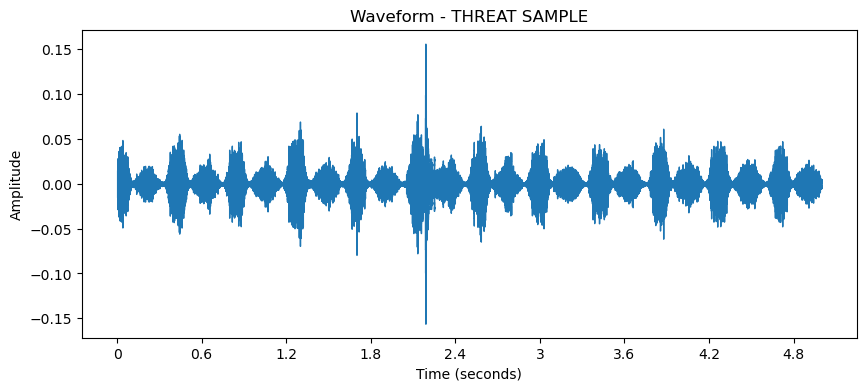

In [43]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(threat_audio,sr=threat_sr)
plt.title("Waveform - THREAT SAMPLE")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

Threat audio sample

In [44]:
ipd.Audio(threat_audio,rate=threat_sr)

Spectrogram of Threat audio.

In [45]:
mel_spectrogram = librosa.feature.melspectrogram(y=threat_audio, sr=threat_sr, n_mels=128)
mel_s_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

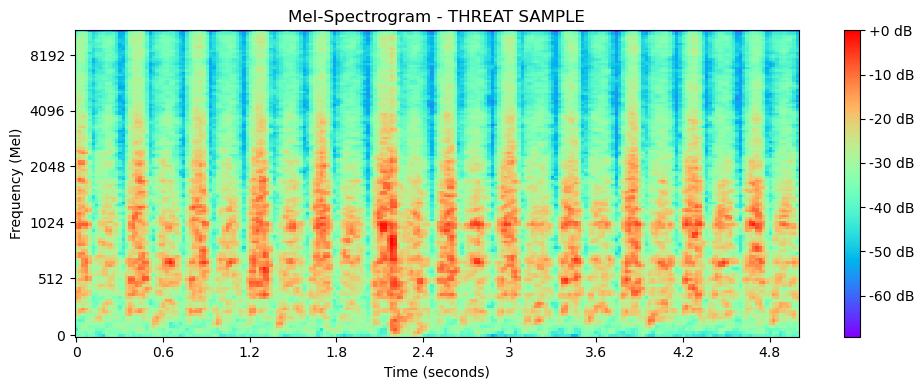

In [46]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_s_db, sr=threat_sr, x_axis='time', y_axis='mel', cmap='rainbow')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel-Spectrogram - THREAT SAMPLE")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Mel)")
plt.tight_layout()
plt.show()

Observations:

- All audio clips are approximately 5 seconds long.
- Sample rate is consistent across the dataset.
- Threat sounds such as chainsaws and engine noises exhibit
  strong high-energy frequency patterns.
- Non-threat sounds such as birds, insects, rain, and wind
  show more natural and diverse spectral characteristics.
- Spectrogram representations appear suitable for CNN-based
  classification.